In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sales = pd.read_csv('./datasets/sales_data.csv')

In [3]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tempo_de_experiencia  100 non-null    int64  
 1   numero_de_vendas      100 non-null    int64  
 2   fator_sazonal         100 non-null    int64  
 3   receita_em_reais      100 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [4]:
df_sales.isna().sum()

tempo_de_experiencia    0
numero_de_vendas        0
fator_sazonal           0
receita_em_reais        0
dtype: int64

### The dataset contains 100 entries and 3 columns. It has no missing values, making it suitable for exploratory data analysis and model training.

In [5]:
df_sales.head(5)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais
0,36,21,5,2639.886941
1,74,44,10,4707.322227
2,38,44,4,5910.035131
3,52,62,6,6130.742546
4,97,56,2,7516.457681


In [6]:
df_sales.describe()

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais
count,100.000000,100.000000,100.000000,100.000000
mean,64.490000,54.490000,5.820000,5112.941924
std,32.397935,25.307201,2.836914,2544.731052
min,1.000000,10.000000,1.000000,1133.363948
25%,38.750000,37.500000,4.000000,2800.660516
50%,64.500000,52.500000,5.000000,4953.770034
75%,93.000000,70.500000,8.000000,7079.500163
max,119.000000,100.000000,10.000000,9941.016458


### Renaming Columns

In [7]:
df_sales.rename(columns={
    'tempo_de_experiencia': 'experience_time',
    'numero_de_vendas': 'sales_count',
    'fator_sazonal': 'seasonal_factor',
    'receita_em_reais': 'revenue_brl'
}, inplace=True)

In [8]:
df_sales.head(5)

,experience_time,sales_count,seasonal_factor,revenue_brl
0,36,21,5,2639.886941
1,74,44,10,4707.322227
2,38,44,4,5910.035131
3,52,62,6,6130.742546
4,97,56,2,7516.457681


### Identifying Outliers

<Axes: xlabel='experience_time'>

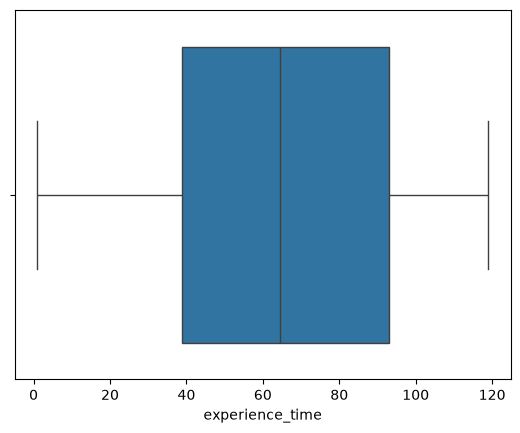

In [9]:
sns.boxplot(data=df_sales, x='experience_time')

<Axes: xlabel='sales_count'>

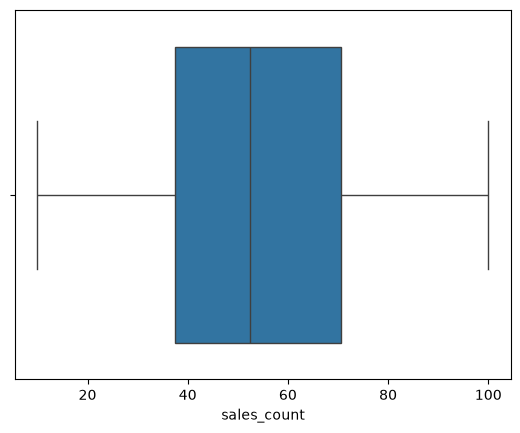

In [10]:
sns.boxplot(data=df_sales, x='sales_count')

<Axes: xlabel='seasonal_factor'>

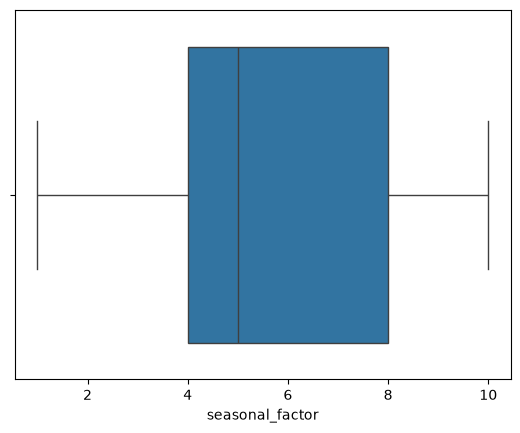

In [11]:
sns.boxplot(data=df_sales, x='seasonal_factor')

<Axes: xlabel='revenue_brl'>

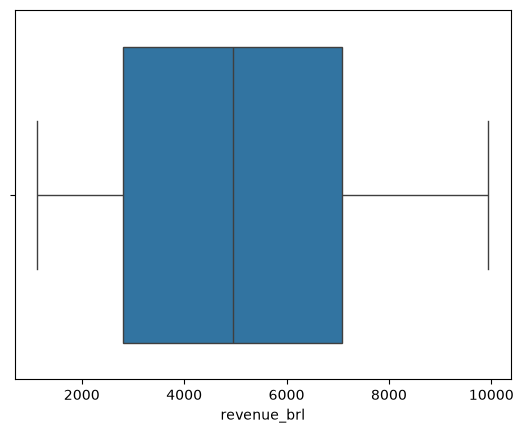

In [12]:
sns.boxplot(data=df_sales, x='revenue_brl')

### Checking feature correlation with target

<Axes: xlabel='experience_time', ylabel='revenue_brl'>

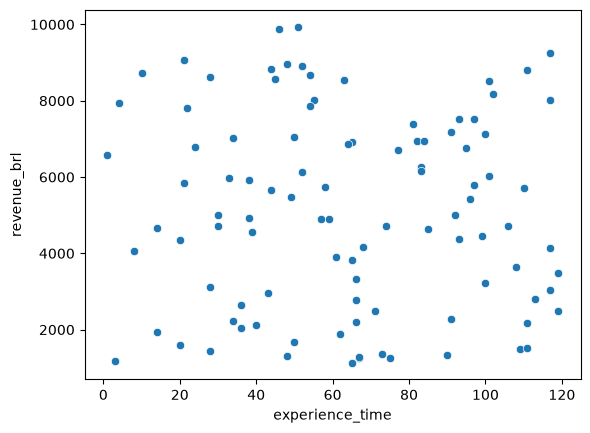

In [13]:
sns.scatterplot(data=df_sales, x='experience_time', y='revenue_brl')

<Axes: xlabel='sales_count', ylabel='revenue_brl'>

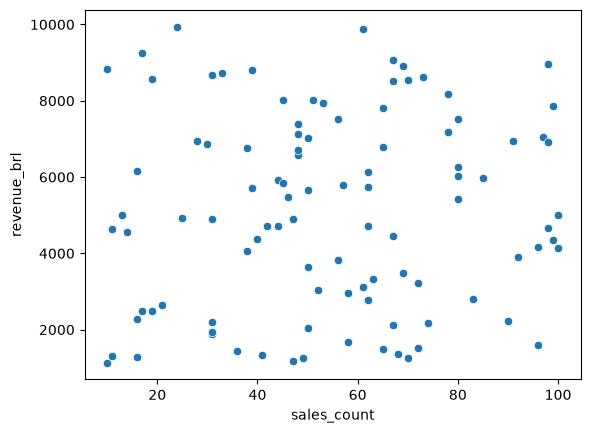

In [14]:
sns.scatterplot(data=df_sales, x='sales_count', y='revenue_brl')

<Axes: xlabel='seasonal_factor', ylabel='revenue_brl'>

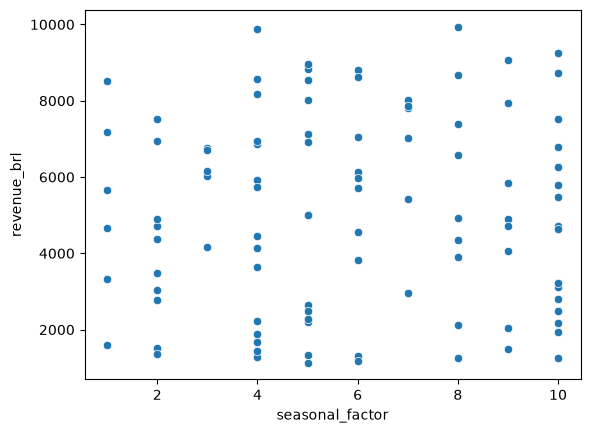

In [15]:
sns.scatterplot(data=df_sales, x='seasonal_factor', y='revenue_brl')

<Axes: xlabel='experience_time', ylabel='sales_count'>

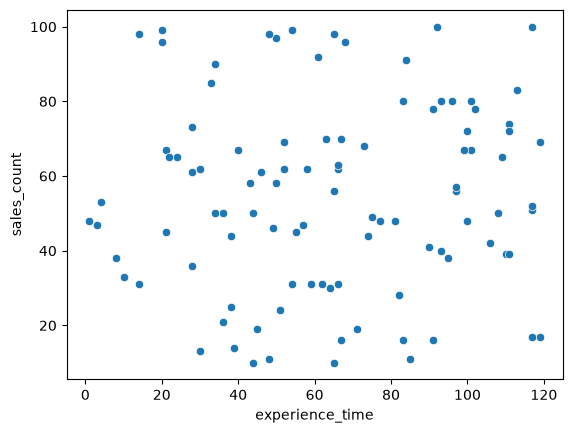

In [16]:
sns.scatterplot(data=df_sales, x='experience_time', y='sales_count')

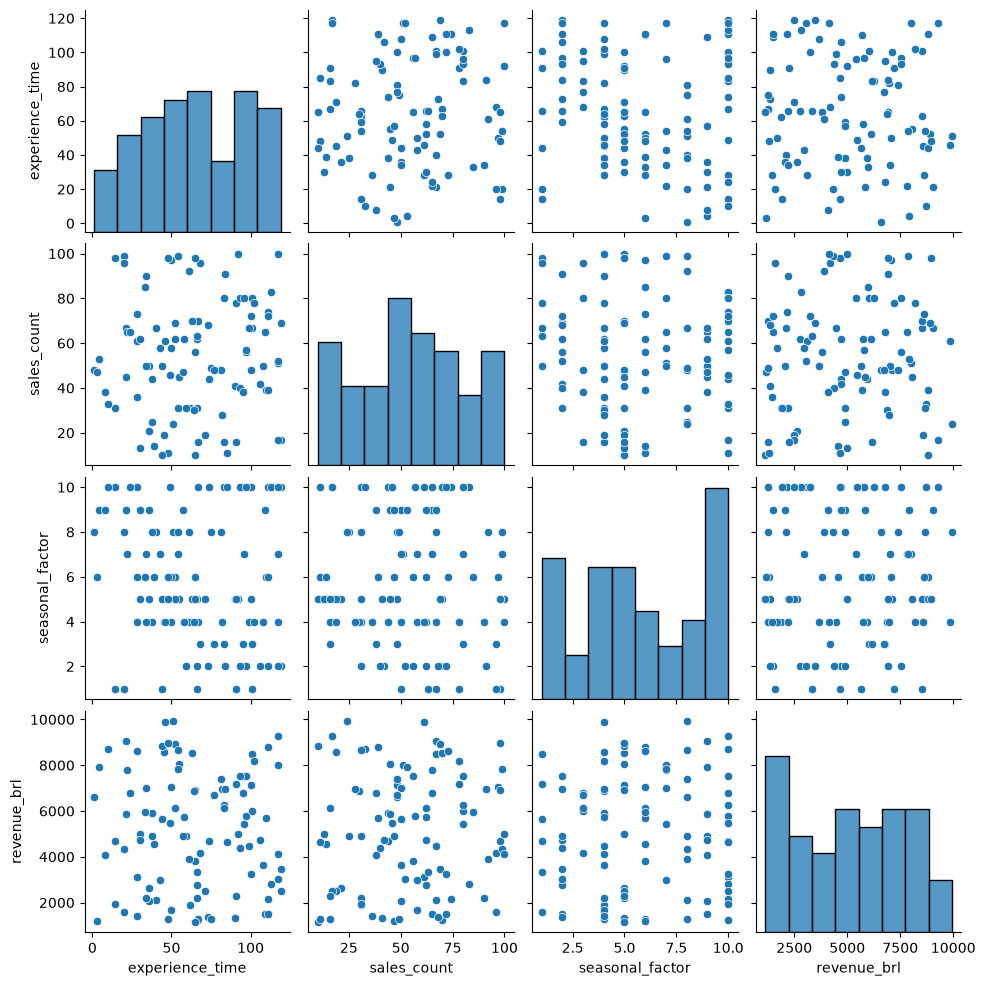

In [17]:
sns.pairplot(data=df_sales)

<Axes: >

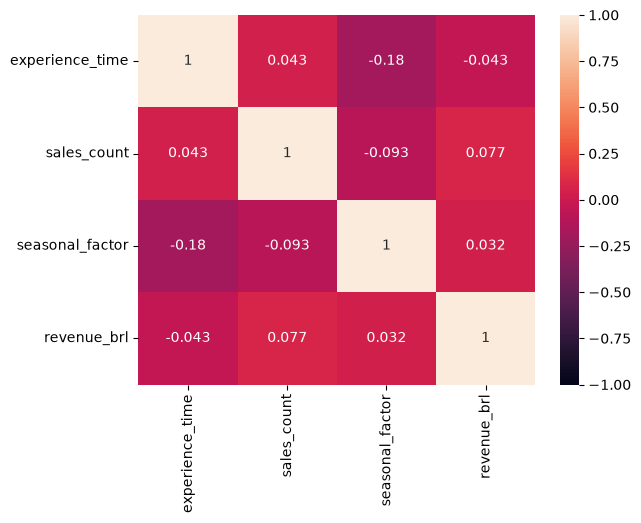

In [18]:
sns.heatmap(data=df_sales.corr(), vmin=-1, vmax=1, annot=True)

### Training model

In [19]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np

In [20]:
X = df_sales.drop(columns='revenue_brl')
y = df_sales['revenue_brl']

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=51)

### Transformer and Model Pipeline

In [30]:
num_columns = ['experience_time', 'sales_count', 'seasonal_factor']

num_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_columns)
    ]
)

# Main Pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Store Training and Testing RMSE Scores
rmse_scores_fold_train = []
rmse_scores_fold_test = []

# Store Testing R² Scores
r2score_fold_test = []

# Store Residuals
residuals = []

# Store Predictions
y_pred_total = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_poly.fit(X_train, y_train)

    # Predict train and test
    y_pred_train = model_poly.predict(X_train)
    y_pred_test = model_poly.predict(X_test)

    # RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # R2score and Residuals
    r2score_test = r2_score(y_test, y_pred_test)
    residuals_test = np.array(y_test - y_pred_test)

    # Store metrics from iteraction
    rmse_scores_fold_train.append(rmse_train)
    rmse_scores_fold_test.append(rmse_test)
    r2score_fold_test.append(r2score_test)
    residuals.append(residuals_test)
    y_pred_total.append(y_pred_test)


rmse_train_final = np.mean(rmse_scores_fold_train)
rmse_test_final = np.mean(rmse_scores_fold_test)
r2score_test_final = np.mean(r2score_fold_test)
percentual_rmse_final = ((rmse_test_final - rmse_train_final) / rmse_train_final) * 100
residuals = np.array(residuals).reshape(-1)
y_pred_total = np.array(y_pred_total).reshape(-1)


In [31]:
print(f'RMSE Train: {rmse_train_final}')
print(f'RMSE Test: {rmse_test_final}')
print(f'% Dif. RMSE Train and Test: {percentual_rmse_final}')
print(f'R2Score Test: {r2score_test_final}')

RMSE Train: 2423.5170534288945
RMSE Test: 2775.008357109534
% Dif. RMSE Train and Test: 14.503355905143497
R2Score Test: -0.24666490724311432


### Residuals analysis

In [35]:
from scipy.stats import zscore
residuals_std = zscore(residuals)

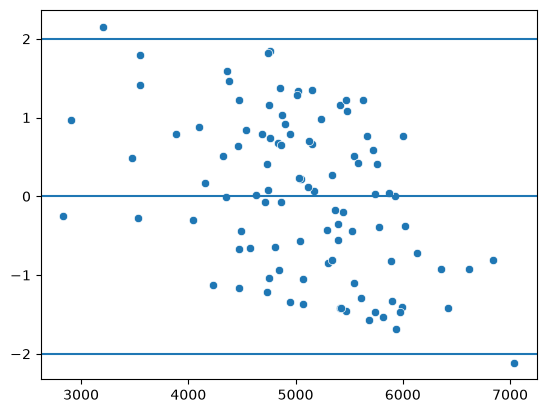

In [37]:
sns.scatterplot(x=y_pred_total, y=residuals_std)
plt.axhline(y=0)
plt.axhline(y=-2)
plt.axhline(y=2)


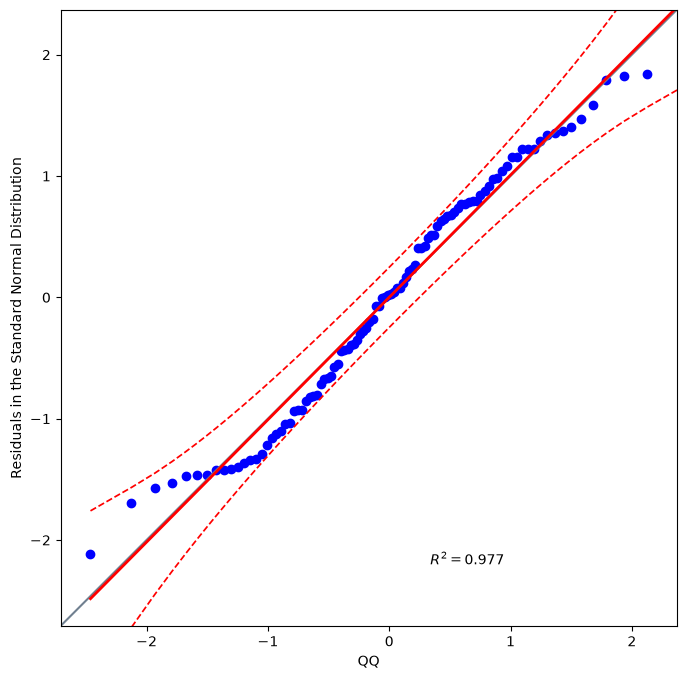

In [40]:
import pingouin as pg
plt.figure(figsize=(14,8))
pg.qqplot(residuals, dist='norm', confidence=0.95)
plt.xlabel('QQ')
plt.ylabel('Residuals in the Standard Normal Distribution')
plt.show()

In [ ]:
# Normality Test - Shapiro-Wilk
from scipy.stats import shapiro, kstest
from statsmodels.stats.diagnostic import lilliefors
stat_shapiro, p_value_shapiro = shapiro(residuals)
print(f"Test Statistic {stat_shapiro} and P-Value {p_value_shapiro}")

Test estatistics 0.9719685335855319 and P-Value 0.031333969408380895


In [43]:
# Normality Test - Kolmogorov-Smirnov
stat_ks, p_value_ks = kstest(residuals, 'norm')
print(f"Test Statistic {stat_ks} and P-Value {p_value_ks}")

Test Statistic 0.53 and P-Value 9.783646983229687e-27


In [46]:
# Normality Test - Lilliefors
stat_ll, p_value_ll = lilliefors(residuals, dist='norm', pvalmethod='table')
print(f"Test Statistic {stat_ll} and P-Value {p_value_ll}")

Test Statistic 0.07546356887253935 and P-Value 0.1851117959681938


In [47]:
import joblib

joblib.dump(model_poly, './sales_revenue_model.pkl')


['./sales_revenue_model.pkl']